In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ziya07/psygenome-mentalhealth-dataset-pg-mhd/PsyGenome_MHD.csv


EDA

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ziya07/psygenome-mentalhealth-dataset-pg-mhd/PsyGenome_MHD.csv")

# Display first rows
df.head()


,Patient_ID,Age,Gender,Family_History,Diagnosis,SNP_1,SNP_2,SNP_3,SNP_4,SNP_5,...,Methyl_1,Methyl_2,Methyl_3,Methyl_4,Methyl_5,Methyl_6,Methyl_7,Methyl_8,Methyl_9,Methyl_10
0,P0001,56,Female,No,Bipolar Disorder,0,0,0,2,2,...,0.022812,0.863495,0.333444,0.156849,0.172709,0.885895,0.654431,0.956346,0.800040,0.767543
1,P0002,69,Male,No,Alzheimer's,0,2,2,0,0,...,0.499821,0.820805,0.412653,0.827000,0.757741,0.678439,0.329716,0.630712,0.506788,0.461543
2,P0003,46,Female,No,Healthy,1,2,1,2,1,...,0.990246,0.504398,0.031986,0.626468,0.728011,0.885184,0.632685,0.019457,0.119744,0.161240
3,P0004,32,Male,No,Healthy,2,1,0,1,2,...,0.211261,0.799777,0.309760,0.312362,0.755587,0.412437,0.064640,0.585126,0.130068,0.571664
4,P0005,60,Male,No,Bipolar Disorder,1,2,0,1,0,...,0.779638,0.929490,0.067053,0.303967,0.652464,0.315453,0.451026,0.020091,0.693498,0.883280


In [3]:
print(df.columns)
print(df.describe())

Index(['Patient_ID', 'Age', 'Gender', 'Family_History', 'Diagnosis', 'SNP_1',
       'SNP_2', 'SNP_3', 'SNP_4', 'SNP_5', 'SNP_6', 'SNP_7', 'SNP_8', 'SNP_9',
       'SNP_10', 'SNP_11', 'SNP_12', 'SNP_13', 'SNP_14', 'SNP_15', 'SNP_16',
       'SNP_17', 'SNP_18', 'SNP_19', 'SNP_20', 'SNP_21', 'SNP_22', 'SNP_23',
       'SNP_24', 'SNP_25', 'SNP_26', 'SNP_27', 'SNP_28', 'SNP_29', 'SNP_30',
       'SNP_31', 'SNP_32', 'SNP_33', 'SNP_34', 'SNP_35', 'SNP_36', 'SNP_37',
       'SNP_38', 'SNP_39', 'SNP_40', 'SNP_41', 'SNP_42', 'SNP_43', 'SNP_44',
       'SNP_45', 'SNP_46', 'SNP_47', 'SNP_48', 'SNP_49', 'SNP_50',
       'GeneExpr_1', 'GeneExpr_2', 'GeneExpr_3', 'GeneExpr_4', 'GeneExpr_5',
       'GeneExpr_6', 'GeneExpr_7', 'GeneExpr_8', 'GeneExpr_9', 'GeneExpr_10',
       'GeneExpr_11', 'GeneExpr_12', 'GeneExpr_13', 'GeneExpr_14',
       'GeneExpr_15', 'GeneExpr_16', 'GeneExpr_17', 'GeneExpr_18',
       'GeneExpr_19', 'GeneExpr_20', 'Methyl_1', 'Methyl_2', 'Methyl_3',
       'Methyl_4', 'Methyl_5'

Checking for missing values in case imputation is needed - it is not

In [4]:
# Check the sum of the missing values 
df.isnull().sum().sort_values(ascending=False)

Patient_ID        0
Age               0
Gender            0
Family_History    0
Diagnosis         0
                 ..
Methyl_6          0
Methyl_7          0
Methyl_8          0
Methyl_9          0
Methyl_10         0
Length: 85, dtype: int64

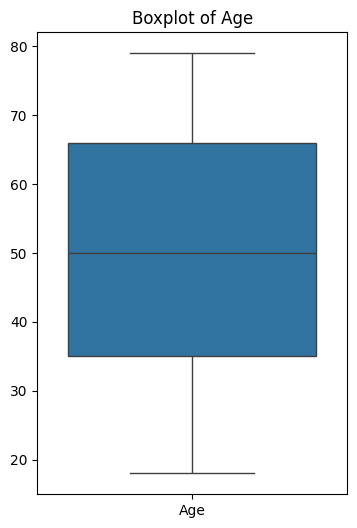

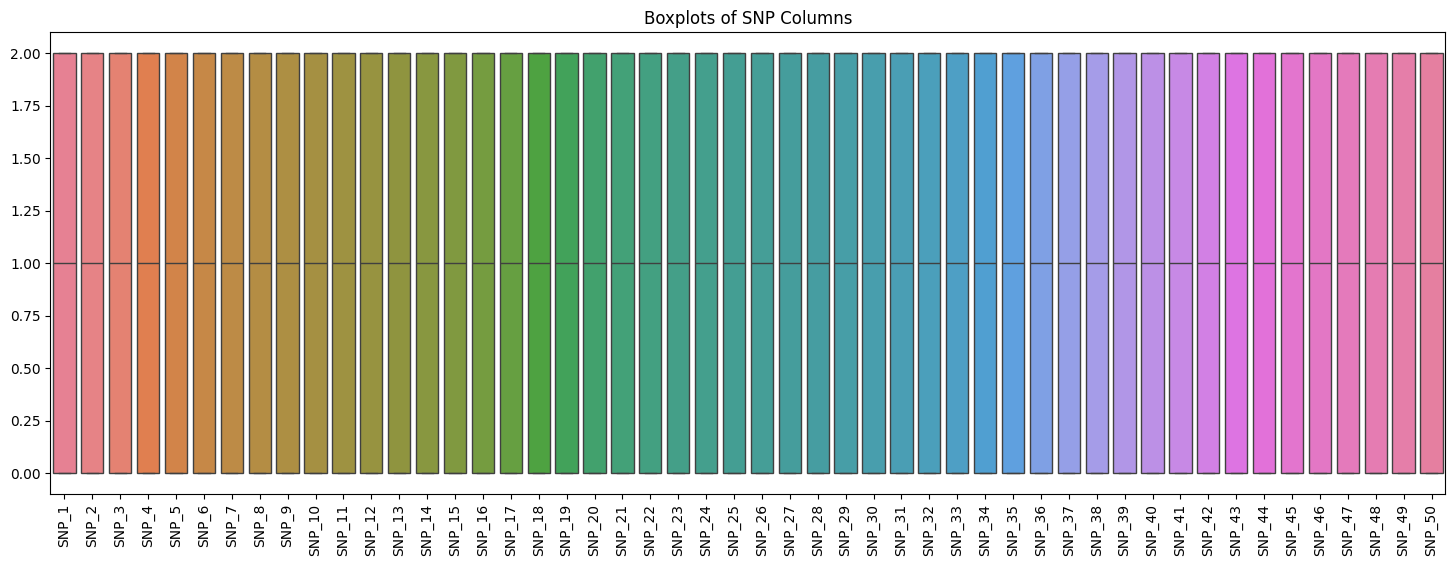

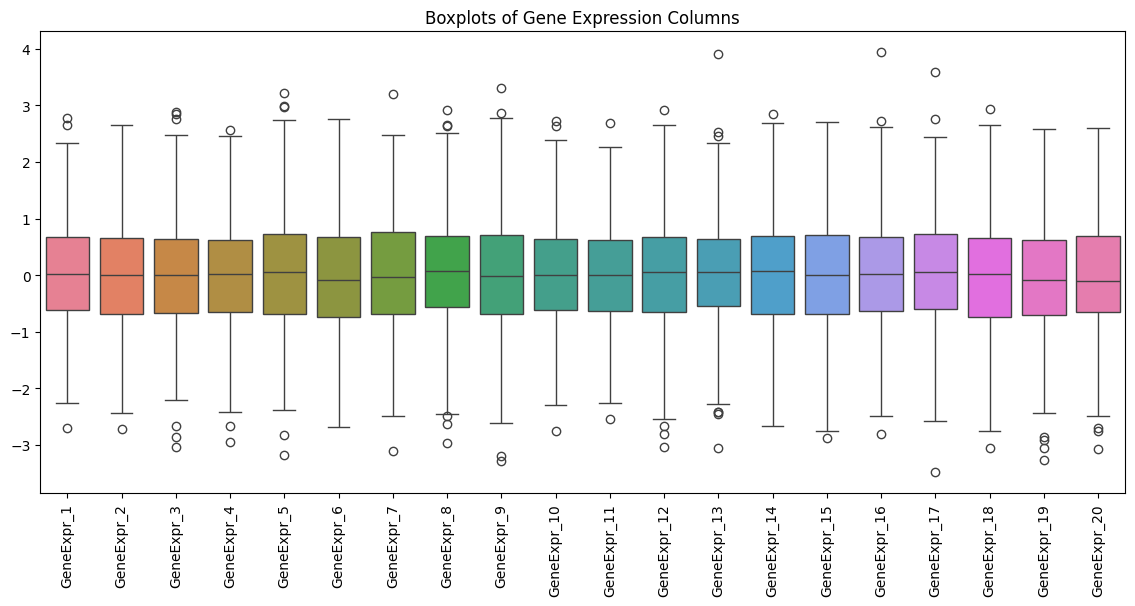

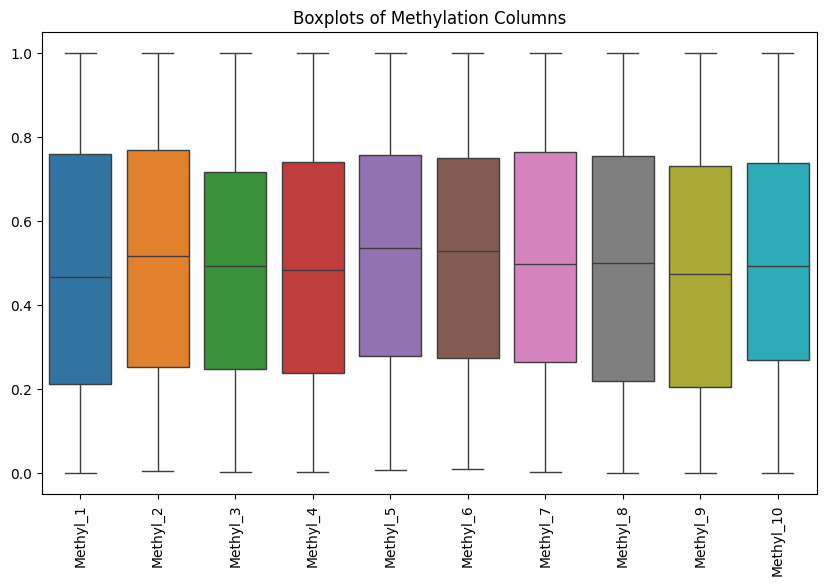

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select groups of columns
age_cols = ['Age']
snp_cols = [col for col in df.columns if col.startswith('SNP_')]
gene_cols = [col for col in df.columns if col.startswith('GeneExpr_')]
methyl_cols = [col for col in df.columns if col.startswith('Methyl_')]

# Age boxplot
plt.figure(figsize=(4, 6))
sns.boxplot(data=df[age_cols])
plt.title("Boxplot of Age")
plt.show()

# SNP boxplots
plt.figure(figsize=(18, 6))
sns.boxplot(data=df[snp_cols])
plt.title("Boxplots of SNP Columns")
plt.xticks(rotation=90)
plt.show()

# Gene expression boxplots
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[gene_cols])
plt.title("Boxplots of Gene Expression Columns")
plt.xticks(rotation=90)
plt.show()

# Methylation boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[methyl_cols])
plt.title("Boxplots of Methylation Columns")
plt.xticks(rotation=90)
plt.show()

Onehot encoding of categorical variables and scaling of numbers

In [6]:
# Target variable - y
df["Diagnosis"].unique()

array(['Bipolar Disorder', "Alzheimer's", 'Healthy', 'Schizophrenia'],
      dtype=object)

In [7]:
df["Diagnosis"].value_counts()

Diagnosis
Bipolar Disorder    136
Alzheimer's         128
Schizophrenia       127
Healthy             109
Name: count, dtype: int64

In [8]:
df.describe().T[["mean","std","min","max"]]

,mean,std,min,max
Age,49.910000,18.221909,18.000000,79.000000
SNP_1,1.052000,0.823804,0.000000,2.000000
SNP_2,0.982000,0.799346,0.000000,2.000000
SNP_3,0.978000,0.801749,0.000000,2.000000
SNP_4,1.018000,0.831299,0.000000,2.000000
...,...,...,...,...
Methyl_6,0.514531,0.281080,0.009338,0.999127
Methyl_7,0.505161,0.289018,0.001108,0.999812
Methyl_8,0.486372,0.300487,0.000482,0.998719
Methyl_9,0.474954,0.295196,0.000248,0.998385


In [9]:
omics_groups = {
    "SNP": [c for c in df.columns if c.startswith("SNP")],
    "GeneExpr": [c for c in df.columns if c.startswith("GeneExpr")],
    "Methyl": [c for c in df.columns if c.startswith("Methyl")]
}

for name, cols in omics_groups.items():
    print(f"\n{name} features summary")
    print(df[cols].describe().loc[["mean","std","min","max"]])


SNP features summary
         SNP_1     SNP_2     SNP_3     SNP_4     SNP_5     SNP_6     SNP_7  \
mean  1.052000  0.982000  0.978000  1.018000  1.010000  1.056000  0.936000   
std   0.823804  0.799346  0.801749  0.831299  0.814387  0.786193  0.805731   
min   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
max   2.000000  2.000000  2.000000  2.000000  2.000000  2.000000  2.000000   

        SNP_8     SNP_9    SNP_10  ...    SNP_41    SNP_42    SNP_43  \
mean  0.99600  0.954000  1.070000  ...  0.948000  1.032000  0.960000   
std   0.80329  0.820506  0.830952  ...  0.809077  0.819952  0.822041   
min   0.00000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
max   2.00000  2.000000  2.000000  ...  2.000000  2.000000  2.000000   

        SNP_44    SNP_45    SNP_46    SNP_47    SNP_48    SNP_49    SNP_50  
mean  1.000000  1.006000  0.982000  1.022000  1.032000  0.986000  0.974000  
std   0.800801  0.811962  0.833706  0.809213  0.815049  0.819235  0.7915

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# drop categorical values and keep numeric
num_cols = df.drop(columns=["Diagnosis","Patient_ID","Gender","Family_History"]).columns

#using columntransformer pipeline tool - handle encoding and scaling in one object
# scales all numerial to mean = 0 SD = 1
# one hot encoding of cat data to binary data
# drops redundent column (dont need multiple cat columns)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), ["Gender","Family_History"])
    ]
)

In [11]:
X = df.drop(columns=["Diagnosis", "Patient_ID"])
y = df["Diagnosis"]

In [12]:
# fit - learn params - transform the data (fit + transform)
X_transformed = preprocessor.fit_transform(X)

In [13]:
# new numeric matrix
print(X_transformed)

[[ 0.33454777 -1.27828144 -1.22973477 ...  0.97295674  0.
   0.        ]
 [ 1.04868916 -1.27828144  1.27481669 ... -0.10423198  1.
   0.        ]
 [-0.21479176 -0.06318501  1.27481669 ... -1.16136598  0.
   0.        ]
 ...
 [ 0.93882125  1.15191141 -1.22973477 ...  1.77636264  1.
   1.        ]
 [-0.0499899  -1.27828144  0.02254096 ... -0.10477187  1.
   0.        ]
 [ 0.7740194   1.15191141  0.02254096 ...  0.0510196   1.
   1.        ]]


In [14]:
# convert transformed array to dataframe 
feature_names = preprocessor.get_feature_names_out()

X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

print(X_transformed_df.head())

   num__Age  num__SNP_1  num__SNP_2  num__SNP_3  num__SNP_4  num__SNP_5  \
0  0.334548   -1.278281   -1.229735   -1.221055    1.182467    1.216855   
1  1.048689   -1.278281    1.274817    1.275990   -1.225816   -1.241438   
2 -0.214792   -0.063185    1.274817    0.027467    1.182467   -0.012291   
3 -0.983867    1.151911    0.022541   -1.221055   -0.021675    1.216855   
4  0.554284   -0.063185    1.274817   -1.221055   -0.021675   -1.241438   

   num__SNP_6  num__SNP_7  num__SNP_8  num__SNP_9  ...  num__Methyl_3  \
0   -1.344526    0.079511    0.004985    0.056119  ...      -0.532077   
1    1.201925    0.079511   -1.241143    1.276099  ...      -0.252189   
2    1.201925   -1.162841    1.251112    1.276099  ...      -1.597301   
3    1.201925    0.079511    0.004985    0.056119  ...      -0.615767   
4   -0.071301    1.321863    1.251112    0.056119  ...      -1.473391   

   num__Methyl_4  num__Methyl_5  num__Methyl_6  num__Methyl_7  num__Methyl_8  \
0      -1.144288      -1.22303

Scaling

In [15]:
X_transformed_df.describe()

,num__Age,num__SNP_1,num__SNP_2,num__SNP_3,num__SNP_4,num__SNP_5,num__SNP_6,num__SNP_7,num__SNP_8,num__SNP_9,...,num__Methyl_3,num__Methyl_4,num__Methyl_5,num__Methyl_6,num__Methyl_7,num__Methyl_8,num__Methyl_9,num__Methyl_10,cat__Gender_Male,cat__Family_History_Yes
count,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,...,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,500.000000,500.000000
mean,1.909584e-16,-3.552714e-17,-1.421085e-17,6.572520e-17,-5.684342e-17,-1.776357e-17,-2.842171e-17,-5.329071e-18,3.552714e-18,1.056932e-16,...,-2.522427e-16,1.776357e-18,1.172396e-16,8.881784e-17,3.552714e-18,5.684342e-17,-1.190159e-16,-2.202682e-16,0.500000,0.522000
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,...,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,0.500501,0.500016
min,-1.752942e+00,-1.278281e+00,-1.229735e+00,-1.221055e+00,-1.225816e+00,-1.241438e+00,-1.344526e+00,-1.162841e+00,-1.241143e+00,-1.163861e+00,...,-1.707062e+00,-1.683097e+00,-1.811549e+00,-1.799126e+00,-1.745767e+00,-1.618627e+00,-1.609715e+00,-1.728607e+00,0.000000,0.000000
25%,-8.190652e-01,-1.278281e+00,-1.229735e+00,-1.221055e+00,-1.225816e+00,-1.241438e+00,-1.344526e+00,-1.162841e+00,-1.241143e+00,-1.163861e+00,...,-8.339321e-01,-8.620927e-01,-8.537085e-01,-8.554976e-01,-8.390522e-01,-8.942394e-01,-9.147839e-01,-7.862498e-01,0.000000,0.000000
50%,4.944056e-03,-6.318501e-02,2.254096e-02,2.746749e-02,-2.167454e-02,-1.229147e-02,-7.130062e-02,7.951053e-02,4.984510e-03,5.611910e-02,...,2.895340e-02,-1.537758e-02,6.092598e-02,4.936571e-02,-2.846300e-02,4.581736e-02,-2.891593e-03,7.555412e-03,0.500000,1.000000
75%,8.838873e-01,1.151911e+00,1.274817e+00,1.275990e+00,1.182467e+00,1.216855e+00,1.201925e+00,1.321863e+00,1.251112e+00,1.276099e+00,...,8.197059e-01,8.764183e-01,8.419794e-01,8.380472e-01,8.937443e-01,8.881443e-01,8.621370e-01,8.700373e-01,1.000000,1.000000
max,1.598029e+00,1.151911e+00,1.274817e+00,1.275990e+00,1.182467e+00,1.216855e+00,1.201925e+00,1.321863e+00,1.251112e+00,1.276099e+00,...,1.817399e+00,1.779218e+00,1.700352e+00,1.725777e+00,1.713206e+00,1.706765e+00,1.774943e+00,1.789882e+00,1.000000,1.000000
